In [1]:
import pandas as pd
import numpy as np
import geopandas as gpd
from shapely.geometry import LineString
import folium
from folium.plugins import Draw
from IPython.display import display, HTML, IFrame
import ast

In [2]:
# Load the dataset
file_path = r'C:\Users\Prakhar.Sarkar\OneDrive - SRP Management Services\Documents\_For_Prakhar\Sample data from Vesna vLandedWells.xlsx'  
df = pd.read_excel(file_path)

In [3]:
def robust_parse(x):
    if pd.isna(x):
        return [None] * 7  # Handle NaNs by returning a list of Nones
    try:
        if isinstance(x, str):
            return ast.literal_eval(x)  # Attempt to parse string as a Python literal
        else:
            return [x] + [None] * 6  # If x is not a string, return it as the first element with None padding
    except Exception as e:
        #print(f"Failed to parse: {x} with error {e}")  # Optionally log the error for debugging
        return [None] * 7  # Return None values if parsing fails

In [4]:
# Columns to be parsed
param_columns = [
    'Oil_Params_P20', 'Gas_Params_P20', 'Oil_Params_P35', 'Gas_Params_P35', 
    'Oil_Params_P50', 'Gas_Params_P50', 'Oil_Params_P65', 'Gas_Params_P65', 
    'Oil_Params_P80', 'Gas_Params_P80', 'Water_Params_P50'
]
# Apply robust parsing to each column
for col in param_columns:
    df[col] = df[col].apply(robust_parse)
# Split each parameter into its own column
new_columns = []
for col in param_columns:
    expanded_cols = [f'{col}_Method', f'{col}_BuildupRate', f'{col}_MonthsInProd', 
                     f'{col}_InitialProd', f'{col}_DiCoefficient', f'{col}_BCoefficient', 
                     f'{col}_MinDeclineRate']
    temp_df = pd.DataFrame(df[col].tolist(), columns=expanded_cols)
    # Convert numeric columns to float
    for num_col in expanded_cols:
        if num_col.endswith('_Method'):
            temp_df[num_col] = temp_df[num_col].astype(str)  # Ensuring 'Method' is of string type
        else:
            temp_df[num_col] = pd.to_numeric(temp_df[num_col], errors='coerce')  # Convert to numeric and handle errors
    df = pd.concat([df, temp_df], axis=1)

# Drop the original parameter columns
df.drop(columns=param_columns, inplace=True)

In [5]:
# Handling NaN values differently for categorical and numerical columns
categorical_columns = df.select_dtypes(include=['object', 'category']).columns.tolist()
for column in df.columns:
    if column in categorical_columns:
        df[column] = df[column].fillna('Unknown')  # Using 'Unknown' for categorical data
    else:
        df[column] = df[column].fillna(0)  # Assuming 0 is a reasonable fill for numerical data
# Drop rows where any of the new parameter columns have missing data
df.dropna(subset=[col for col in df.columns if 'Params' in col], inplace=True)

In [6]:
# Drop rows where 'FluidPerFoot_bblft' or 'ProppantPerFoot' are zero
df = df[(df['FluidPerFoot_bblft'] != 0) & (df['ProppantPerFoot'] != 0)]
df = df[(df['EUR_30yr_Actual_Gas_P50_MMCF'] != 0) & (df['EUR_30yr_Actual_Oil_P50_MBO'] != 0) & (df['EUR_30yr_Actual_Water_P50_MBBL'] != 0)]
df = df[(df['HEELPOINT_LAT'] != 0)]

In [7]:
# Define a function to replace zeros with the P50 value for the same category
def replace_zeros_with_P50(df):
    # Replace for EUR values
    phases = ['Oil', 'Gas', 'Water']  # Assuming Water is also needed; adjust as necessary
    years = ['30yr']  # Adjust or extend if there are other year ranges
    
    for phase in phases:
        for year in years:
            p50_col = f'EUR_{year}_Actual_{phase}_P50_' + ('MBO' if phase != 'Gas' else 'MMCF')
            if phase == 'Water':
                p50_col = f'EUR_{year}_Actual_{phase}_P50_MBBL'  # Assuming water is measured in MBBL

            for p in ['P20', 'P35', 'P65', 'P80']:
                p_col = f'EUR_{year}_Actual_{phase}_{p}_' + ('MBO' if phase != 'Gas' else 'MMCF')
                if phase == 'Water':
                    p_col = f'EUR_{year}_Actual_{phase}_{p}_MBBL'
                
                if p_col in df.columns and p50_col in df.columns:
                    df.loc[df[p_col] == 0, p_col] = df[p50_col]

    # Replace for parameters
    params = ['Method', 'BuildupRate', 'MonthsInProd', 'InitialProd', 'DiCoefficient', 'BCoefficient', 'MinDeclineRate']
    for phase in ['Oil', 'Gas', 'Water']:  # Assuming Water parameters are also needed
        for param in params:
            p50_col = f'{phase}_Params_P50_{param}'
            for p in ['P20', 'P35', 'P65', 'P80']:
                p_col = f'{phase}_Params_{p}_{param}'
                if p_col in df.columns and p50_col in df.columns:
                    df.loc[df[p_col] == 0, p_col] = df[p50_col]

In [8]:
replace_zeros_with_P50(df)

In [9]:
# Drop rows where latitude or longitude values are missing
df.dropna(subset=['HEELPOINT_LAT', 'HEELPOINT_LON', 'MIDPOINT_LAT', 'MIDPOINT_LON', 'TOEPOINT_LAT', 'TOEPOINT_LON'], inplace=True)

# Create a GeoDataFrame
gdf = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(df['HEELPOINT_LON'], df['HEELPOINT_LAT']))

# Create a LineString for each well
gdf['line'] = gdf.apply(lambda row: LineString([
    (row['HEELPOINT_LON'], row['HEELPOINT_LAT']),
    (row['MIDPOINT_LON'], row['MIDPOINT_LAT']),
    (row['TOEPOINT_LON'], row['TOEPOINT_LAT'])
]), axis=1)

# Create a GeoDataFrame with the LineStrings
line_gdf = gpd.GeoDataFrame(gdf, geometry='line')

# Calculate bounds to set the map's initial view
bounds = line_gdf.total_bounds  # [minx, miny, maxx, maxy]
center = [(bounds[1] + bounds[3]) / 2, (bounds[0] + bounds[2]) / 2]  # [(miny + maxy)/2, (minx + maxx)/2]

# Create a folium map centered on the calculated center
m = folium.Map(location=center, zoom_start=10)

# Fit map to bounds
m.fit_bounds([[bounds[1], bounds[0]], [bounds[3], bounds[2]]])


# Add the lines to the map
for _, row in line_gdf.iterrows():
    line_points = [
        (row['HEELPOINT_LAT'], row['HEELPOINT_LON']),
        (row['MIDPOINT_LAT'], row['MIDPOINT_LON']),
        (row['TOEPOINT_LAT'], row['TOEPOINT_LON'])
    ]
    folium.PolyLine(line_points, color='blue').add_to(m)
    # Add marker for midpoint with a popup showing coordinates or other info
    folium.Marker(location=line_points[1], popup=f'Well ID: {row["WellName"]}', tooltip='Click for info').add_to(m)

# Add draw control to the map to allow for area selection
draw = Draw(export=True)
m.add_child(draw)

# Display the map in the Jupyter notebook
m.save('wells_map.html')
display(IFrame('wells_map.html', width=700, height=500))


In [10]:
def add_neighbor_eur(df):
    if df is None:
        raise ValueError("The input DataFrame is None. Please provide a valid DataFrame.")

    # Check if the UWI column exists
    if 'UWI' not in df.columns:
        raise ValueError("The input DataFrame does not contain the 'UWI' column.")

    # Define the EUR columns we're interested in
    eur_oil_columns = ['EUR_30yr_Actual_Oil_P20_MBO', 'EUR_30yr_Actual_Oil_P35_MBO', 
                       'EUR_30yr_Actual_Oil_P50_MBO', 'EUR_30yr_Actual_Oil_P65_MBO', 
                       'EUR_30yr_Actual_Oil_P80_MBO']
    eur_gas_columns = ['EUR_30yr_Actual_Gas_P20_MMCF', 'EUR_30yr_Actual_Gas_P35_MMCF', 
                       'EUR_30yr_Actual_Gas_P50_MMCF', 'EUR_30yr_Actual_Gas_P65_MMCF', 
                       'EUR_30yr_Actual_Gas_P80_MMCF']

    # Check if the required EUR columns exist
    missing_columns = [col for col in eur_oil_columns + eur_gas_columns if col not in df.columns]
    if missing_columns:
        raise ValueError(f"The input DataFrame is missing the following required columns: {missing_columns}")

    # Create a mapping DataFrame that will be used for mapping EUR values
    eur_map = df.set_index('UWI')[eur_oil_columns + eur_gas_columns].fillna(0).copy()

    # Iterate over NNAZ and NNSZ columns
    for prefix in ['NNAZ', 'NNSZ']:
        num_cols = 6 if prefix == 'NNAZ' else 2  # Assuming 6 NNAZ and 2 NNSZ columns
        for i in range(1, num_cols + 1):
            uwi_col = f'{prefix}_{i}_UWI'
            if uwi_col in df.columns:  # Ensure the UWI column exists
                for eur_col in eur_oil_columns + eur_gas_columns:
                    new_col_name = f'{prefix}_{i}_{eur_col}'
                    # Use the map function to add EUR values from the eur_map DataFrame
                    df[new_col_name] = df[uwi_col].map(eur_map[eur_col])

    return df

In [11]:
df = add_neighbor_eur(df)

In [12]:
columns_to_drop=['UWI10', 'CompletionDate' ,'UWI', 'WellName','NNAZ_1_UWI','NNAZ_2_UWI','NNAZ_3_UWI','NNAZ_4_UWI','NNAZ_5_UWI','NNAZ_6_UWI','NNSZ_1_UWI',
                'NNSZ_2_UWI','LeaseName', 'WellNumber', 'CurrentOperatorName', 'OriginalOperatorName', 'DrillingContractorName', 'PermitDate', 'SpudDate','FORMATION_CONDENSE', 'Unique_PDP_ID']
# Dropping the columns
df.drop(columns=columns_to_drop, inplace=True)
months_in_prod_columns = [col for col in df.columns if '_MonthsInProd' in col]
df.drop(months_in_prod_columns, axis=1, inplace=True)
months_in_prod_columns = [col for col in df.columns if '_Method' in col]
df.drop(months_in_prod_columns, axis=1, inplace=True)
months_in_prod_columns = [col for col in df.columns if '_MinDeclineRate' in col]
df.drop(months_in_prod_columns, axis=1, inplace=True)

In [13]:
# Display the DataFrame after dropping the rows
print(df.describe())

       HORIZONTIAL_WELL_LENGTH  EST_FORMATION_THICKNESS  PERCENT_IN_ZONE  \
count              1026.000000              1026.000000      1026.000000   
mean              10215.764113               281.789649         0.984113   
std                1770.474369                88.392873         0.065259   
min                4013.230000                77.260000         0.510000   
25%                9772.100000               210.382500         1.000000   
50%               10355.185000               269.695000         1.000000   
75%               10710.815000               370.587500         1.000000   
max               15749.620000               666.140000         1.000000   

       AVERAGE_DEPTH_BELOW_TOP  AVERAGE_INCLINATION  WELL_TORTUOSITY  \
count              1026.000000          1026.000000      1026.000000   
mean               -145.500390            -0.069711         0.000558   
std                  79.498664             2.822956         0.000230   
min                -635.050

In [14]:
# Define bounds for each basin in a dictionary.
# The keys are basin names, and the values are tuples of (lat_min, lat_max, lon_min, lon_max).
basin_bounds = {
    'Midland': {'lat_range': (31, 33), 'lon_range': (-105, -100)}
    # Add more basins with their geographic bounds 
}
def assign_basin_tc(row):
    # Check if BasinTC is 0 or missing (use pd.isna() and explicitly handle pd.NA)
    if pd.isna(row['BasinTC']) or row['BasinTC'] == 0:
        matched_basin = None
        for basin, bounds in basin_bounds.items():
            # Ensure all comparisons are done within bounds
            if ((bounds['lat_range'][0] <= row['HEELPOINT_LAT'] <= bounds['lat_range'][1] and
                 bounds['lon_range'][0] <= row['HEELPOINT_LON'] <= bounds['lon_range'][1]) or
                (bounds['lat_range'][0] <= row['MIDPOINT_LAT'] <= bounds['lat_range'][1] and
                 bounds['lon_range'][0] <= row['MIDPOINT_LON'] <= bounds['lon_range'][1]) or
                (bounds['lat_range'][0] <= row['TOEPOINT_LAT'] <= bounds['lat_range'][1] and
                 bounds['lon_range'][0] <= row['TOEPOINT_LON'] <= bounds['lon_range'][1])):
                matched_basin = basin
                break
        return matched_basin if matched_basin else row['BasinTC']
    return row['BasinTC']

In [15]:
# Apply the function to each row
#df['BasinTC'] = df.apply(assign_basin_tc, axis=1)
df['BasinTC'] ='Midland'
df.reset_index(drop=True, inplace=True)
df_orig = df

In [16]:
# Re-apply the assignment function
#df['BasinTC'] = df.apply(assign_basin_tc, axis=1)

# Check for rows where BasinTC remains as 'Unknown' or NA
#unknown_count = df[df['BasinTC'].isna() | (df['BasinTC'] == 0)].shape[0]
#print(f"Remaining 'Unknown' or unassigned BasinTC entries: {unknown_count}")

In [17]:
#Encoding for Categorical Data
from sklearn.preprocessing import LabelEncoder

In [18]:
# Auto-detect categorical columns
categorical_columns = df.select_dtypes(include=['object', 'category']).columns.tolist()
numerical_columns = [col for col in df.columns if col not in categorical_columns]

In [32]:
list(feature_columns)

['PRIMARY_FORMATION',
 'Typecurve',
 'BasinTC',
 'HORIZONTIAL_WELL_LENGTH',
 'EST_FORMATION_THICKNESS',
 'PERCENT_IN_ZONE',
 'AVERAGE_DEPTH_BELOW_TOP',
 'AVERAGE_INCLINATION',
 'WELL_TRAJECTORY',
 'WELL_TORTUOSITY',
 'PRIMARY_FORMATION_1Q',
 'DEPTH_TO_TOP_1Q',
 'PRIMARY_FORMATION_2Q',
 'DEPTH_TO_TOP_2Q',
 'PRIMARY_FORMATION_3Q',
 'DEPTH_TO_TOP_3Q',
 'PRIMARY_FORMATION_4Q',
 'DEPTH_TO_TOP_4Q',
 'AZIMUTH',
 'NNAZ_1_FORMATION',
 'NNAZ_1_TRUEDIST',
 'NNAZ_1_HZDIST',
 'NNAZ_1_VTDIST',
 'NNAZ_2_FORMATION',
 'NNAZ_2_TRUEDIST',
 'NNAZ_2_HZDIST',
 'NNAZ_2_VTDIST',
 'NNAZ_3_FORMATION',
 'NNAZ_3_TRUEDIST',
 'NNAZ_3_HZDIST',
 'NNAZ_3_VTDIST',
 'NNAZ_4_FORMATION',
 'NNAZ_4_TRUEDIST',
 'NNAZ_4_HZDIST',
 'NNAZ_4_VTDIST',
 'NNAZ_5_FORMATION',
 'NNAZ_5_TRUEDIST',
 'NNAZ_5_HZDIST',
 'NNAZ_5_VTDIST',
 'NNAZ_6_FORMATION',
 'NNAZ_6_TRUEDIST',
 'NNAZ_6_HZDIST',
 'NNAZ_6_VTDIST',
 'NNSZ_1_FORMATION',
 'NNSZ_1_TRUEDIST',
 'NNSZ_1_HZDIST',
 'NNSZ_1_VTDIST',
 'NNSZ_2_FORMATION',
 'NNSZ_2_TRUEDIST',
 'NNSZ_2_HZD

In [19]:
# Calculate the number of unique categories and their names for each column
category_info = {col: {'count': df[col].nunique(), 'names': df[col].unique()} for col in categorical_columns}
# Print the number of categories grouped by the header name
for header, info in category_info.items():
    print(f"{header}:")
    print(f"  Count of Categories: {info['count']}")
    print(f"  Categories: {info['names']}\n")

PRIMARY_FORMATION:
  Count of Categories: 13
  Categories: ['SPBYLC1' 'WFMPA1' 'WFMPB1' 'SPBYMA1' 'WFMPD' 'SPBYLA2' 'Dean' 'SPBYLB1'
 'Wolfcamp B' 'WFMPC1' 'Wolfcamp A' 'SPBYLA1' 'Lower Spraberry']

Typecurve:
  Count of Categories: 15
  Categories: ['proj101_North' 'Mercury_600' 'proj353' 'proj53' 'Mercury_700' 'proj393'
 'proj58' 'proj96_B' 'proj193' 'proj214_East' 'proj205' 'Unknown'
 'proj278' 'proj214_West' 'proj48_B']

BasinTC:
  Count of Categories: 1
  Categories: ['Midland']

WELL_TRAJECTORY:
  Count of Categories: 3
  Categories: ['Flat' 'Toe Down' 'Toe Up']

PRIMARY_FORMATION_1Q:
  Count of Categories: 10
  Categories: ['SPBYLC1' 'WFMPA1' 'WFMPB1' 'SPBYMA1' 'WFMPD' 'SPBYLA2' 'Dean' 'SPBYLB1'
 'WFMPC1' 'SPBYLA1']

PRIMARY_FORMATION_2Q:
  Count of Categories: 10
  Categories: ['SPBYLC1' 'WFMPA1' 'WFMPB1' 'SPBYMA1' 'WFMPD' 'SPBYLA2' 'Dean' 'SPBYLB1'
 'WFMPC1' 'SPBYLA1']

PRIMARY_FORMATION_3Q:
  Count of Categories: 10
  Categories: ['SPBYLC1' 'WFMPA1' 'WFMPB1' 'SPBYMA1' 'WFMPD'

In [20]:
# Initialize a dictionary to keep LabelEncoders for each column
encoders = {}
# Encode categorical columns and store the encoders
for col in categorical_columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))  # Convert and encode
    encoders[col] = le  # Store the encoder for inverse_transform

In [21]:
#category_info = {col: {'count': len(encoders[col].classes_), 'names': encoders[col].classes_} for col in categorical_columns}

# Print category information
#for header, info in category_info.items():
#    print(f"{header}:")
  #  print(f"  Count of Categories: {info['count']}")
  #  print(f"  Categories: {info['names']}\n")

In [22]:
# Function to find non-convertible columns
#def find_non_convertible_columns(dataframe, columns):
   # non_convertible_columns = []
   # for column in columns:
   #     try:
   #         dataframe[column].astype(np.float32)
    #    except ValueError:
   #         non_convertible_columns.append(column)
   # return non_convertible_columns

In [23]:
# Applying the function to your DataFrame
#non_convertible_columns = find_non_convertible_columns(df, numerical_columns)
#print("Columns that cannot be converted to float32:", non_convertible_columns)

In [24]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.layers import Input, Dense, Flatten, Concatenate, Embedding, Reshape
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import Model
from keras_tuner import HyperModel
import matplotlib.pyplot as plt
from tensorflow.keras.callbacks import Callback
from keras.callbacks import Callback
import time
from keras_tuner.tuners import RandomSearch
from sklearn.model_selection import train_test_split

In [25]:
# Prepare data for modeling
y_headers = [col for col in df.columns if 'Params' in col]             # Define target headers dynamically if needed
feature_columns = [col for col in df.columns if col not in y_headers]  # Features including numerical and categorical

In [26]:
# Split data
train_df, test_df = train_test_split(df, test_size=0.3, random_state=42)
val_df, test_df = train_test_split(test_df, test_size=0.5, random_state=42)

In [27]:
# Extract features and targets
x_train = train_df[feature_columns]
y_train = train_df[y_headers].values.astype(np.float32) # Ensure targets are in float32

x_val = val_df[feature_columns]
y_val = val_df[y_headers].values.astype(np.float32)

x_test = test_df[feature_columns]
y_test = test_df[y_headers].values.astype(np.float32)

# Segregate features into numerical and categorical based on the initial columns lists
x_train_numerical = x_train[feature_columns].values.astype(np.float32) # Convert numerical data
x_train_categorical = x_train[categorical_columns].values.astype(np.int32) # Keep categorical data as integers (ensure they are encoded correctly as integers)

x_val_numerical = x_val[feature_columns].values.astype(np.float32)
x_val_categorical = x_val[categorical_columns].values.astype(np.int32)

x_test_numerical = x_test[feature_columns].values.astype(np.float32)
x_test_categorical = x_test[categorical_columns].values.astype(np.int32)

In [28]:
# RealTimePlottingCallback definition
class RealTimePlottingCallback(Callback):
    def __init__(self):
        super().__init__()
        self.start_time = time.time()

    def on_train_begin(self, logs=None):
        self.epochs = []
        self.losses = []
        self.val_losses = []
        
        plt.ion()  # Turn on interactive mode
        self.fig, self.ax = plt.subplots(1, 1)
        self.ax.set_xlabel('Epochs')
        self.ax.set_ylabel('Loss')
        self.ax.set_title('Training and Validation Loss Over Time')

    def on_epoch_end(self, epoch, logs=None):
        time_elapsed = time.time() - self.start_time
        self.epochs.append(epoch)  # Using epoch count instead of time for x-axis
        self.losses.append(logs['loss'])
        self.val_losses.append(logs.get('val_loss', None))  # Safe access to validation loss

        # Clear current plot
        self.ax.clear()
        self.ax.set_xlabel('Epochs')
        self.ax.set_ylabel('Loss')
        self.ax.set_title('Training and Validation Loss Over Time')
        self.ax.plot(self.epochs, self.losses, label='Train', color='blue')
        if self.val_losses[0] is not None:
            self.ax.plot(self.epochs, self.val_losses, label='Validation', color='red')
        self.ax.legend(loc='upper right')
        
        plt.draw()
        plt.pause(0.001)

    def on_train_end(self, logs=None):
        plt.ioff()  # Turn off interactive mode
        plt.show()

In [29]:
# Define embedding layer creation function
def create_embedding_layer(num_categories, embedding_dim):
    return layers.Embedding(input_dim=num_categories + 1, output_dim=embedding_dim)

In [30]:
class GANHyperModel(HyperModel):
    def __init__(self, input_dim, categorical_details, target_shape):
        self.input_dim = input_dim
        self.categorical_details = categorical_details
        self.target_shape = target_shape
    
    def build_generator(self, hp):
        # Noise input
        noise_input = Input(shape=(self.input_dim,), name='noise_input')

        # Categorical inputs
        categorical_inputs = [Input(shape=(1,), name=f'cat_input_{i}') for i, _ in enumerate(self.categorical_details)]

        # Embeddings for categorical inputs
        embeddings = [
            Embedding(input_dim=detail['num_categories'] + 1, output_dim=detail['embedding_dim'], name=f'embedding_{i}')(cat_input)
            for i, (detail, cat_input) in enumerate(zip(self.categorical_details, categorical_inputs))
        ]
        flat_embeddings = [Flatten()(emb) for emb in embeddings]

        # Concatenate noise and embeddings
        merged_input = Concatenate()(flat_embeddings + [noise_input])

        # Generator network
        x = Dense(hp.Int('units_g', min_value=256, max_value=1024, step=256), activation='relu')(merged_input)
        x = Dense(np.prod(self.target_shape), activation='tanh')(x)
        output = Reshape(self.target_shape)(x)

        return Model(inputs=[noise_input] + categorical_inputs, outputs=output, name="generator")

    def build_discriminator(self, hp):
        model_input = Input(shape=self.target_shape, name='discriminator_input')
        x = Flatten()(model_input)
        x = Dense(hp.Int('units_d', min_value=256, max_value=1024, step=256), activation='relu')(x)
        x = Dense(1, activation='sigmoid')(x)

        return Model(inputs=model_input, outputs=x, name="discriminator")

    def build(self, hp):
        generator = self.build_generator(hp)
        discriminator = self.build_discriminator(hp)

        # Set up the discriminator
        discriminator.compile(optimizer=Adam(hp.Choice('lr_d', [1e-5, 1e-3])), loss='binary_crossentropy')
        discriminator.trainable = False

        # Set up the full GAN
        gan_input = [Input(shape=(self.input_dim,), name='noise_input')] + [Input(shape=(1,), name=f'cat_input_{i}') for i in range(len(self.categorical_details))]
        gan_output = discriminator(generator(gan_input))
        gan = Model(inputs=gan_input, outputs=gan_output, name='gan')

        gan.compile(optimizer=Adam(hp.Choice('lr_g', [1e-5, 1e-3])), loss='binary_crossentropy')

        return gan

Trial 2 Complete [00h 00m 01s]

Best loss So Far: None
Total elapsed time: 00h 00m 03s

Search: Running Trial #3

Value             |Best Value So Far |Hyperparameter
512               |256               |units_g
512               |1024              |units_d
0.4               |0.4               |dropout_d
1.552e-05         |0.00022524        |lr_d
9.3688e-05        |6.5931e-05        |lr_g

Epoch 1/10


Traceback (most recent call last):
  File "C:\Users\Prakhar.Sarkar\AppData\Local\miniconda3\Lib\site-packages\keras_tuner\src\engine\base_tuner.py", line 274, in _try_run_and_update_trial
    self._run_and_update_trial(trial, *fit_args, **fit_kwargs)
  File "C:\Users\Prakhar.Sarkar\AppData\Local\miniconda3\Lib\site-packages\keras_tuner\src\engine\base_tuner.py", line 239, in _run_and_update_trial
    results = self.run_trial(trial, *fit_args, **fit_kwargs)
              ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Prakhar.Sarkar\AppData\Local\miniconda3\Lib\site-packages\keras_tuner\src\engine\tuner.py", line 314, in run_trial
    obj_value = self._build_and_fit_model(trial, *args, **copied_kwargs)
                ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Prakhar.Sarkar\AppData\Local\miniconda3\Lib\site-packages\keras_tuner\src\engine\tuner.py", line 233, in _build_and_fit_model
    results = self.hypermodel.fit(hp, model, *args, **kwa

RuntimeError: Number of consecutive failures exceeded the limit of 3.
Traceback (most recent call last):
  File "C:\Users\Prakhar.Sarkar\AppData\Local\miniconda3\Lib\site-packages\keras_tuner\src\engine\base_tuner.py", line 274, in _try_run_and_update_trial
    self._run_and_update_trial(trial, *fit_args, **fit_kwargs)
  File "C:\Users\Prakhar.Sarkar\AppData\Local\miniconda3\Lib\site-packages\keras_tuner\src\engine\base_tuner.py", line 239, in _run_and_update_trial
    results = self.run_trial(trial, *fit_args, **fit_kwargs)
              ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Prakhar.Sarkar\AppData\Local\miniconda3\Lib\site-packages\keras_tuner\src\engine\tuner.py", line 314, in run_trial
    obj_value = self._build_and_fit_model(trial, *args, **copied_kwargs)
                ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Prakhar.Sarkar\AppData\Local\miniconda3\Lib\site-packages\keras_tuner\src\engine\tuner.py", line 233, in _build_a

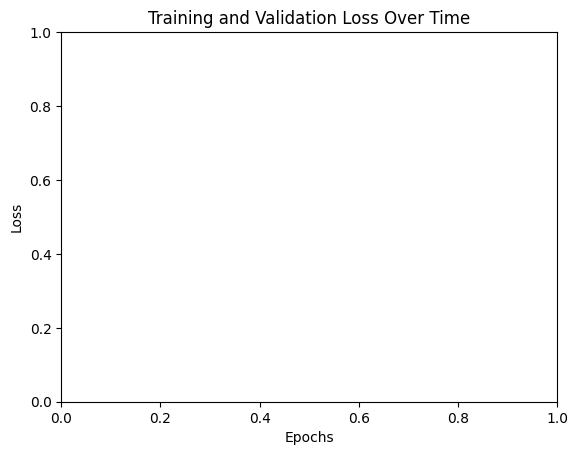

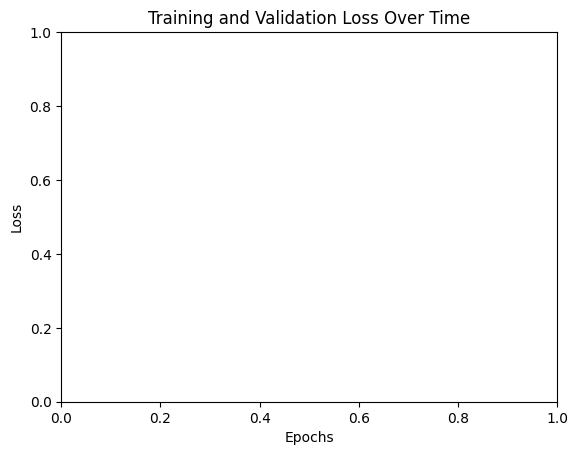

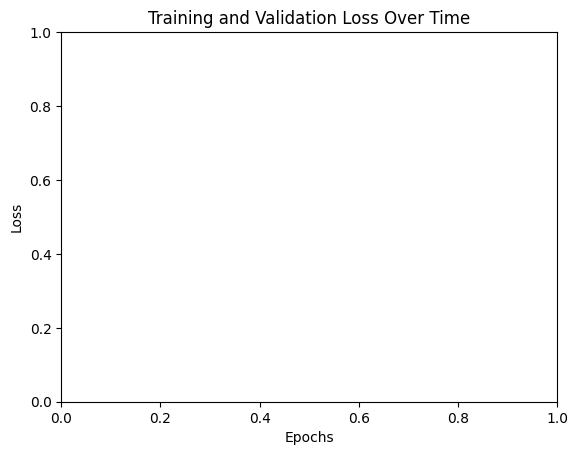

In [31]:
# Calculate the number of unique categories for each categorical column to define embedding sizes
categorical_details = [{'num_categories': df[col].nunique(), 'embedding_dim': min(50, (df[col].nunique() // 2 + 1))} for col in categorical_columns]

# Define the dimensions for noise and embedding inputs
input_shape = (100,)  # Dimension for the noise input

# Instantiate the GAN HyperModel
hypermodel = GANHyperModel(input_dim=input_shape[0], categorical_details=categorical_details, target_shape=(y_train.shape[1],))

# Setup the tuner
tuner = RandomSearch(
    hypermodel,
    objective='loss',
    max_trials=10,
    executions_per_trial=2,
    directory='test_directory',
    project_name='gan_project'
)

# Real-time plotting callback
real_time_plotter = RealTimePlottingCallback()

# Setup data for noise and categorical inputs during training
noise_train = np.random.normal(0, 1, (len(x_train), input_shape[0]))
categorical_inputs_train = [x_train[col].values for col in categorical_columns]
noise_val = np.random.normal(0, 1, (len(x_val), input_shape[0]))
categorical_inputs_val = [x_val[col].values for col in categorical_columns]

# Add the callback to the tuner search
tuner.search(
    {'noise_input': noise_train, 'cat_inputs': categorical_inputs_train},
    y_train,
    epochs=10,
    validation_data=(
        {'noise_input': noise_val, 'cat_inputs': categorical_inputs_val},
        y_val
    ),
    callbacks=[real_time_plotter]
)

In [ ]:
#best_model = tuner.get_best_models(num_models=1)[0]